<a href="https://colab.research.google.com/github/ClaudioRo81/Data_Scientist/blob/main/RetoTecnicoCoppel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Reto Tecnico

**Objetivo:** Evaluar tus habilidades para analizar datos, identificar patrones y generar insights accionables a partir
de la información disponible sobre el servicio de asesorías de Home Center. No hay respuestas buenas o malas,
queremos ver y saber cómo resuelves el problema.

**Contexto:**
Home Center, empresa que comercializa materiales de construcción, remodelación y productos para el hogar, ha
experimentado un aumento en las quejas de clientes sobre su servicio de asesorías en los últimos 3 meses.
Esto ha provocado una caída del 30% en los indicadores de satisfacción y una disminución en las ventas
subsecuentes a la asesoría.

**Información:**
- **Datos de ventas:** Información sobre las ventas derivadas del servicio de asesoría en los últimos meses,
desglosadas por sucursales y canal en línea (ver gráfico)
-** Datos de clientes:** Bases de datos con información demográfica, historial de compras y uso del servicio
de asesorías. ( Datos de Clientes ) Utiliza datos dummy con mínimo 5,000 registros
- **Métricas de negocio:** Indicadores clave de rendimiento (KPIs) relacionados con el servicio de asesorías,
incluyendo el número de asesorías realizadas, tasa de conversión a ventas, satisfacción del cliente, etc.
( Métricas de Negocio (KPIs_Asesorias) ) Utiliza datos dummy con mínimo 5,000 registros
- **Datos de Google Analytics:** Información sobre el comportamiento de los usuarios en el sitio web de
Home Center, incluyendo páginas visitadas, tiempo de permanencia, tasa de rebote, etc.,
especialmente en las secciones relacionadas con el servicio de asesorías. (
Datos de Google Analytics (GA_Asesorias) ) Utiliza datos dummy con mínimo 5,000 registros
- **Quejas de clientes:** Registro de las quejas recibidas sobre el servicio de asesorías, incluyendo la fecha,
el canal (sucursal o en línea), el motivo de la queja y la información del cliente. (
Quejas de Clientes (Quejas_Clientes) ) Utiliza datos dummy con mínimo 5,000 registros

##Generacion de la data usando las plantillas

In [ ]:
#Instalar dependencia
!pip install pandas numpy openpyxl

In [ ]:
import pandas as pd
import numpy as np
from datetime import timedelta

# 1. Configuración Inicial y Fechas
np.random.seed(42)
n_clientes = 5500

# Fechas para los 5 meses (Asumiremos de Enero a Mayo para el caso)
fechas_meses = [
    (pd.to_datetime('2024-01-01'), pd.to_datetime('2024-01-31')), # Mes 1
    (pd.to_datetime('2024-02-01'), pd.to_datetime('2024-02-28')), # Mes 2
    (pd.to_datetime('2024-03-01'), pd.to_datetime('2024-03-31')), # Mes 3 (Inicia el problema)
    (pd.to_datetime('2024-04-01'), pd.to_datetime('2024-04-30')), # Mes 4
    (pd.to_datetime('2024-05-01'), pd.to_datetime('2024-05-31'))  # Mes 5
]

def random_dates(start, end, n):
    start_u = start.value // 10**9
    end_u = end.value // 10**9
    return pd.to_datetime(np.random.randint(start_u, end_u, n), unit='s')

# ---------------------------------------------------------
# 2. BASE DE CLIENTES
# ---------------------------------------------------------
clientes_id = [f"CLI-{str(i).zfill(5)}" for i in range(1, n_clientes + 1)]
segmentos = ['Mejoras Pequeñas', 'Profesional']

df_clientes = pd.DataFrame({
    'ID_Cliente': clientes_id,
    'Segmento': np.random.choice(segmentos, n_clientes, p=[0.7, 0.3]),
    'Historial_Compras': np.round(np.random.uniform(1000, 50000, n_clientes), 2)
})

# ---------------------------------------------------------
# 3. MÉTRICAS DE NEGOCIO (Asesorías y Ventas)
# ---------------------------------------------------------
asesorias = []
id_asesoria_counter = 1

# Probabilidades de conversión y satisfacción base
base_conv = {'Sucursal': 0.6, 'En línea': 0.5}
base_csat = [0.05, 0.05, 0.1, 0.3, 0.5] # Sesgado a 4 y 5 estrellas

for mes_idx, (start, end) in enumerate(fechas_meses):
    # En los últimos 3 meses, caen los indicadores drásticamente (especialmente en línea)
    is_crisis = mes_idx >= 2

    n_asesorias_mes = int(np.random.normal(2000, 200)) # Unas 2000 asesorias por mes
    clientes_mes = np.random.choice(clientes_id, n_asesorias_mes)
    canales_mes = np.random.choice(['Sucursal', 'En línea'], n_asesorias_mes, p=[0.55, 0.45])
    fechas = random_dates(start, end, n_asesorias_mes)

    for i in range(n_asesorias_mes):
        canal = canales_mes[i]

        # Penalización por la "crisis" en el servicio
        if is_crisis:
            if canal == 'En línea':
                prob_conv = 0.15 # Caída brutal en línea
                csat_probs = [0.4, 0.3, 0.15, 0.1, 0.05] # Sesgado a 1 y 2 estrellas
            else:
                prob_conv = 0.40 # Caída moderada en sucursal
                csat_probs = [0.2, 0.2, 0.3, 0.2, 0.1]
        else:
            prob_conv = base_conv[canal]
            csat_probs = base_csat

        conversion = np.random.choice([1, 0], p=[prob_conv, 1 - prob_conv])

        # Monto de venta (solo si hay conversión)
        monto = 0
        if conversion == 1:
            monto = np.round(np.random.uniform(500, 15000), 2)

        asesorias.append({
            'ID_Asesoria': f"ASES-{str(id_asesoria_counter).zfill(5)}",
            'Fecha_Asesoria': fechas[i],
            'ID_Cliente': clientes_mes[i],
            'Canal': canal,
            'Asesor_Responsable': f"ASR-{str(np.random.randint(1, 20)).zfill(2)}",
            'Satisfaccion_Post_Asesoria': np.random.choice([1, 2, 3, 4, 5], p=csat_probs),
            'Conversion_Venta': conversion,
            'Monto_Venta_MXN': monto
        })
        id_asesoria_counter += 1

df_kpis = pd.DataFrame(asesorias)

# ---------------------------------------------------------
# 4. QUEJAS DE CLIENTES
# ---------------------------------------------------------
quejas = []
id_queja_counter = 1
motivos = ['Asesoría incompleta', 'Información incorrecta', 'Fallas en plataforma', 'Tiempo de espera', 'Mala actitud']

for mes_idx, (start, end) in enumerate(fechas_meses):
    # Pocas quejas al principio, se disparan del mes 3 en adelante
    n_quejas = np.random.randint(50, 100) if mes_idx < 2 else np.random.randint(400, 800)
    fechas = random_dates(start, end, n_quejas)

    for i in range(n_quejas):
        canal = np.random.choice(['Sucursal', 'En línea'], p=[0.3, 0.7] if mes_idx >= 2 else [0.5, 0.5])

        if canal == 'En línea' and mes_idx >= 2:
            motivo = np.random.choice(motivos, p=[0.2, 0.1, 0.5, 0.1, 0.1]) # En crisis online, domina "Fallas en plataforma"
        else:
            motivo = np.random.choice(motivos, p=[0.3, 0.3, 0.05, 0.2, 0.15])

        quejas.append({
            'ID_Queja': f"QUEJ-{str(id_queja_counter).zfill(5)}",
            'Fecha_Queja': fechas[i],
            'ID_Cliente': np.random.choice(clientes_id),
            'Canal': canal,
            'Motivo_Queja': motivo
        })
        id_queja_counter += 1

df_quejas = pd.DataFrame(quejas)

# ---------------------------------------------------------
# 5. GOOGLE ANALYTICS (Navegación Web)
# ---------------------------------------------------------
sesiones = []
id_sesion_counter = 1
paginas = ['/inicio', '/productos', '/asesoria_online', '/promociones']

for mes_idx, (start, end) in enumerate(fechas_meses):
    n_sesiones = int(np.random.normal(3000, 300))
    fechas = random_dates(start, end, n_sesiones)

    for i in range(n_sesiones):
        is_crisis = mes_idx >= 2
        # Si estamos en crisis, la tasa de rebote sube y los clics en asesoría bajan
        tasa_rebote = np.random.uniform(0.6, 0.95) if is_crisis else np.random.uniform(0.2, 0.5)
        prob_clic = 0.05 if is_crisis else 0.25

        sesiones.append({
            'ID_Sesion': f"SESS-{str(id_sesion_counter).zfill(5)}",
            'Fecha_Sesion': fechas[i],
            'ID_Cliente': np.random.choice(clientes_id) if np.random.random() > 0.3 else np.nan, # 30% usuarios no logueados
            'Pagina_Inicio': np.random.choice(paginas, p=[0.4, 0.3, 0.2, 0.1]),
            'Tasa_Rebote': np.round(tasa_rebote, 2),
            'Clic_Solicitud_Asesoria': np.random.choice([1, 0], p=[prob_clic, 1 - prob_clic])
        })
        id_sesion_counter += 1

df_ga = pd.DataFrame(sesiones)

# ---------------------------------------------------------
# 6. EXPORTAR A EXCEL (Sobreescribiendo los archivos)
# ---------------------------------------------------------
df_clientes.to_excel('Datos de Clientes.xlsx', index=False)
df_kpis.to_excel('Métricas de Negocio (KPIs_Asesorias).xlsx', index=False)
df_quejas.to_excel('Quejas de Clientes (Quejas_Clientes).xlsx', index=False)
df_ga.to_excel('Datos de Google Analytics (GA_Asesorias).xlsx', index=False)

print(f"Archivos generados con éxito.")
print(f"- Clientes: {len(df_clientes)} registros")
print(f"- KPIs Asesorías: {len(df_kpis)} registros")
print(f"- Quejas: {len(df_quejas)} registros")
print(f"- Sesiones GA: {len(df_ga)} registros")

Archivos generados con éxito.
- Clientes: 5500 registros
- KPIs Asesorías: 9663 registros
- Quejas: 2007 registros
- Sesiones GA: 14858 registros


=== 1. TENDENCIA DE VENTAS SUBSECUENTES ===


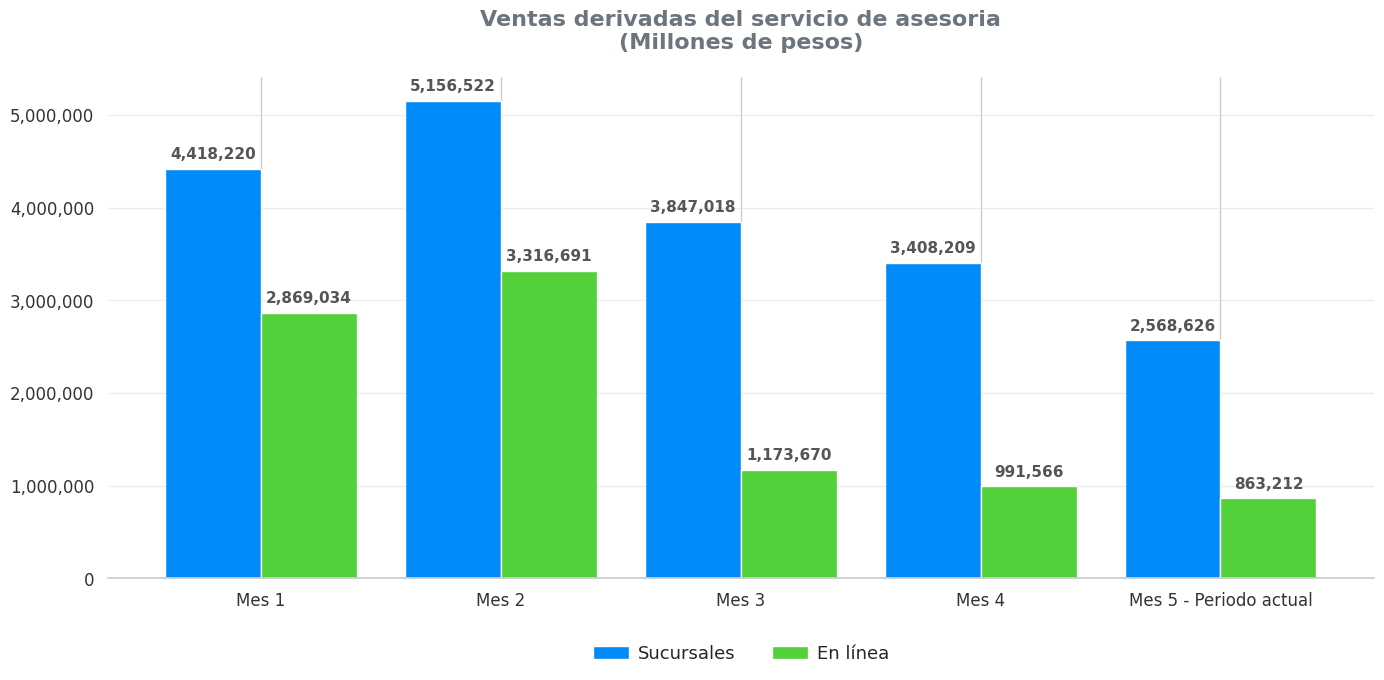


=== 2. SEGMENTACIÓN: TIPO DE CLIENTE Y CANAL ===
Segmento Mejoras Pequeñas               Profesional              
Canal            En línea      Sucursal    En línea      Sucursal
Mes_Num                                                          
1           $2,018,153.49 $3,134,339.22 $850,880.91 $1,283,880.78
2           $2,354,936.81 $3,608,050.23 $961,754.97 $1,548,472.69
3             $783,841.22 $2,832,913.08 $389,829.74 $1,014,105.69
4             $741,566.39 $2,385,582.89 $250,000.55 $1,022,627.06
5             $686,537.78 $1,841,534.81 $176,674.81   $727,091.55

=== 3. KPIS AFECTADOS VS VOLUMEN DE QUEJAS ===
         Tasa_Conversion_%  CSAT_Promedio  Total_Quejas
Mes_Num                                                
1                   $52.79          $4.13            73
2                   $54.95          $4.12            99
3                   $28.69          $2.50           608
4                   $29.13          $2.55           702
5                   $27.08          $2

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 1. Cargar y preparar los datos unidos
df_clientes = pd.read_excel('Datos de Clientes.xlsx')
df_kpis = pd.read_excel('Métricas de Negocio (KPIs_Asesorias).xlsx')
df_quejas = pd.read_excel('Quejas de Clientes (Quejas_Clientes).xlsx')

# Unimos KPIs con Clientes para tener la visión completa
df_merged = pd.merge(df_kpis, df_clientes, on='ID_Cliente', how='left')
df_merged['Mes_Num'] = df_merged['Fecha_Asesoria'].dt.month
df_quejas['Mes_Num'] = df_quejas['Fecha_Queja'].dt.month

# ==========================================
# GRÁFICO 1: REPLICA EJECUTIVA (BARRAS)
# ==========================================
print("=== 1. TENDENCIA DE VENTAS SUBSECUENTES ===")
ventas = df_merged[df_merged['Conversion_Venta'] == 1].groupby(['Mes_Num', 'Canal'])['Monto_Venta_MXN'].sum().unstack()

# Definir colores corporativos de la imagen original
color_sucursal = '#008BF8' # Azul brillante
color_en_linea = '#52D13A' # Verde brillante

fig, ax = plt.subplots(figsize=(14, 7))

# Preparar las posiciones de las barras
x = np.arange(len(ventas.index))
width = 0.40 # Ancho de las barras

# Crear las barras para cada canal
rects1 = ax.bar(x - width/2, ventas['Sucursal'], width, label='Sucursales', color=color_sucursal, edgecolor='white')
rects2 = ax.bar(x + width/2, ventas['En línea'], width, label='En línea', color=color_en_linea, edgecolor='white')

# Título y formato base (Color grisáceo para replicar la imagen)
ax.set_title('Ventas derivadas del servicio de asesoria\n(Millones de pesos)',
             fontsize=16, color='#6c757d', pad=20, fontweight='bold')

# Etiquetas del eje X (Personalizando el mes 5)
labels = ['Mes 1', 'Mes 2', 'Mes 3', 'Mes 4', 'Mes 5 - Periodo actual']
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, color='#333333')

# Formato del eje Y con comas separadoras de miles
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: format(int(val), ',')))
ax.tick_params(axis='y', labelsize=12, colors='#333333')

# Función para poner el valor exacto encima de cada barra
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{int(height):,}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 puntos de separación vertical
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=11, color='#555555', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# Limpieza del gráfico (Quitar bordes innecesarios y agregar cuadrícula tenue)
ax.grid(axis='y', linestyle='-', alpha=0.6, color='#e0e0e0')
ax.set_axisbelow(True) # Enviar cuadrícula al fondo
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')

# Leyenda en la parte inferior central
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=13, handletextpad=0.5)

plt.tight_layout()
plt.show()

# ==========================================
# IMPRESIONES DE CONSOLA (EDA)
# ==========================================
print("\n=== 2. SEGMENTACIÓN: TIPO DE CLIENTE Y CANAL ===")
segmentacion = df_merged[df_merged['Conversion_Venta'] == 1].groupby(['Mes_Num', 'Segmento', 'Canal'])['Monto_Venta_MXN'].sum().unstack(level=[1,2])
# Aplicamos formato de moneda a la tabla de consola para que sea más ejecutiva
pd.options.display.float_format = '${:,.2f}'.format
print(segmentacion)

print("\n=== 3. KPIS AFECTADOS VS VOLUMEN DE QUEJAS ===")
kpis_mensual = df_merged.groupby('Mes_Num').agg({
    'Conversion_Venta': lambda x: round(x.mean() * 100, 2),
    'Satisfaccion_Post_Asesoria': lambda x: round(x.mean(), 2)
}).rename(columns={'Conversion_Venta': 'Tasa_Conversion_%', 'Satisfaccion_Post_Asesoria': 'CSAT_Promedio'})

kpis_mensual['Total_Quejas'] = df_quejas.groupby('Mes_Num').size()
print(kpis_mensual)

print("\n=== 4. ANÁLISIS DE COHORTES (PRE VS POST CRISIS) ===")
df_merged['Cohorte'] = np.where(df_merged['Mes_Num'] <= 2, 'Pre-Crisis (Mes 1-2)', 'Post-Crisis (Mes 3-5)')
cohorte_analysis = df_merged.groupby('Cohorte').agg({
    'Conversion_Venta': lambda x: f"{round(x.mean() * 100, 2)}%",
    'Satisfaccion_Post_Asesoria': lambda x: round(x.mean(), 2),
    'Monto_Venta_MXN': lambda x: f"${round(x.mean(), 2):,}"
})
print(cohorte_analysis)

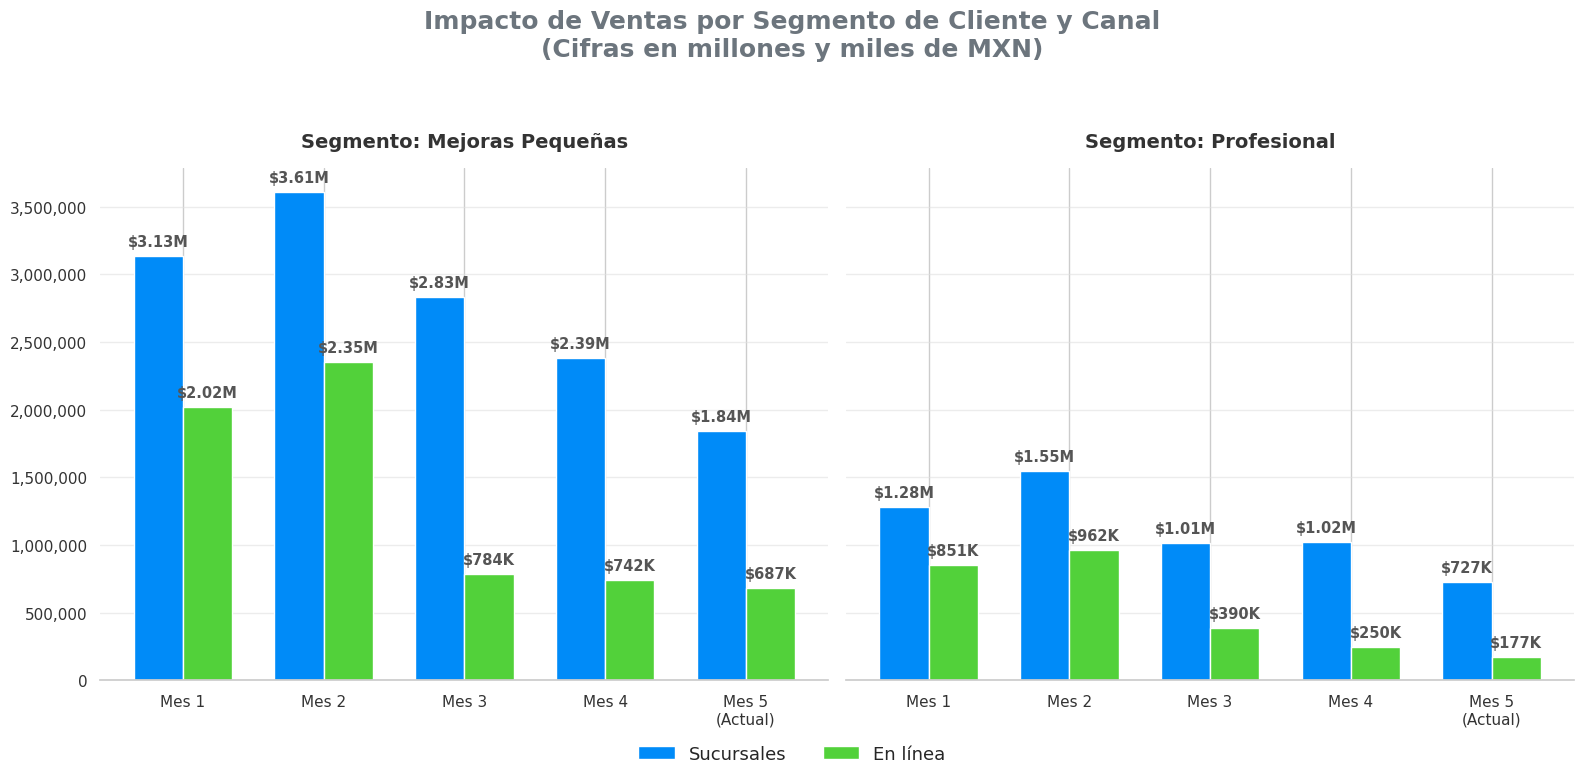

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# 1. Preparar los datos de segmentación
segmentacion = df_merged[df_merged['Conversion_Venta'] == 1].groupby(['Mes_Num', 'Segmento', 'Canal'])['Monto_Venta_MXN'].sum().unstack(level=[1,2])

# 2. Configuración visual corporativa
color_sucursal = '#008BF8' # Azul brillante
color_en_linea = '#52D13A' # Verde brillante

# Crear figura con 2 paneles (uno por cada segmento de cliente)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
fig.suptitle('Impacto de Ventas por Segmento de Cliente y Canal\n(Cifras en millones y miles de MXN)',
             fontsize=18, color='#6c757d', fontweight='bold', y=1.05)

x = np.arange(len(segmentacion.index))
width = 0.35 # Ancho de las barras
x_labels = ['Mes 1', 'Mes 2', 'Mes 3', 'Mes 4', 'Mes 5\n(Actual)']

# ==========================================
# PANEL 1: Mejoras Pequeñas
# ==========================================
data_mp = segmentacion['Mejoras Pequeñas']
rects1_mp = ax1.bar(x - width/2, data_mp['Sucursal'], width, label='Sucursales', color=color_sucursal, edgecolor='white')
rects2_mp = ax1.bar(x + width/2, data_mp['En línea'], width, label='En línea', color=color_en_linea, edgecolor='white')

ax1.set_title('Segmento: Mejoras Pequeñas', fontsize=14, fontweight='bold', color='#333333', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, fontsize=11, color='#333333')

# ==========================================
# PANEL 2: Profesional
# ==========================================
data_prof = segmentacion['Profesional']
rects1_prof = ax2.bar(x - width/2, data_prof['Sucursal'], width, label='Sucursales', color=color_sucursal, edgecolor='white')
rects2_prof = ax2.bar(x + width/2, data_prof['En línea'], width, label='En línea', color=color_en_linea, edgecolor='white')

ax2.set_title('Segmento: Profesional', fontsize=14, fontweight='bold', color='#333333', pad=15)
ax2.set_xticks(x)
ax2.set_xticklabels(x_labels, fontsize=11, color='#333333')

# ==========================================
# FORMATO Y LIMPIEZA
# ==========================================
# Función ejecutiva para etiquetas: formatea a Millones (M) o Miles (K) para no saturar la vista
def autolabel_executive(rects, ax):
    for rect in rects:
        height = rect.get_height()
        if height >= 1000000:
            label = f'${height/1000000:.2f}M'
        elif height > 0:
            label = f'${height/1000:.0f}K'
        else:
            label = ''

        if label:
            ax.annotate(label,
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10.5, color='#555555', fontweight='bold')

autolabel_executive(rects1_mp, ax1)
autolabel_executive(rects2_mp, ax1)
autolabel_executive(rects1_prof, ax2)
autolabel_executive(rects2_prof, ax2)

# Formatear el eje Y y limpiar los bordes en ambos subplots
for ax in [ax1, ax2]:
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda val, pos: format(int(val), ',')))
    ax.grid(axis='y', linestyle='-', alpha=0.6, color='#e0e0e0')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(axis='y', labelsize=11, colors='#333333')

# Agregar una única leyenda global centrada en la parte inferior
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False, fontsize=13)

plt.tight_layout()
plt.show()

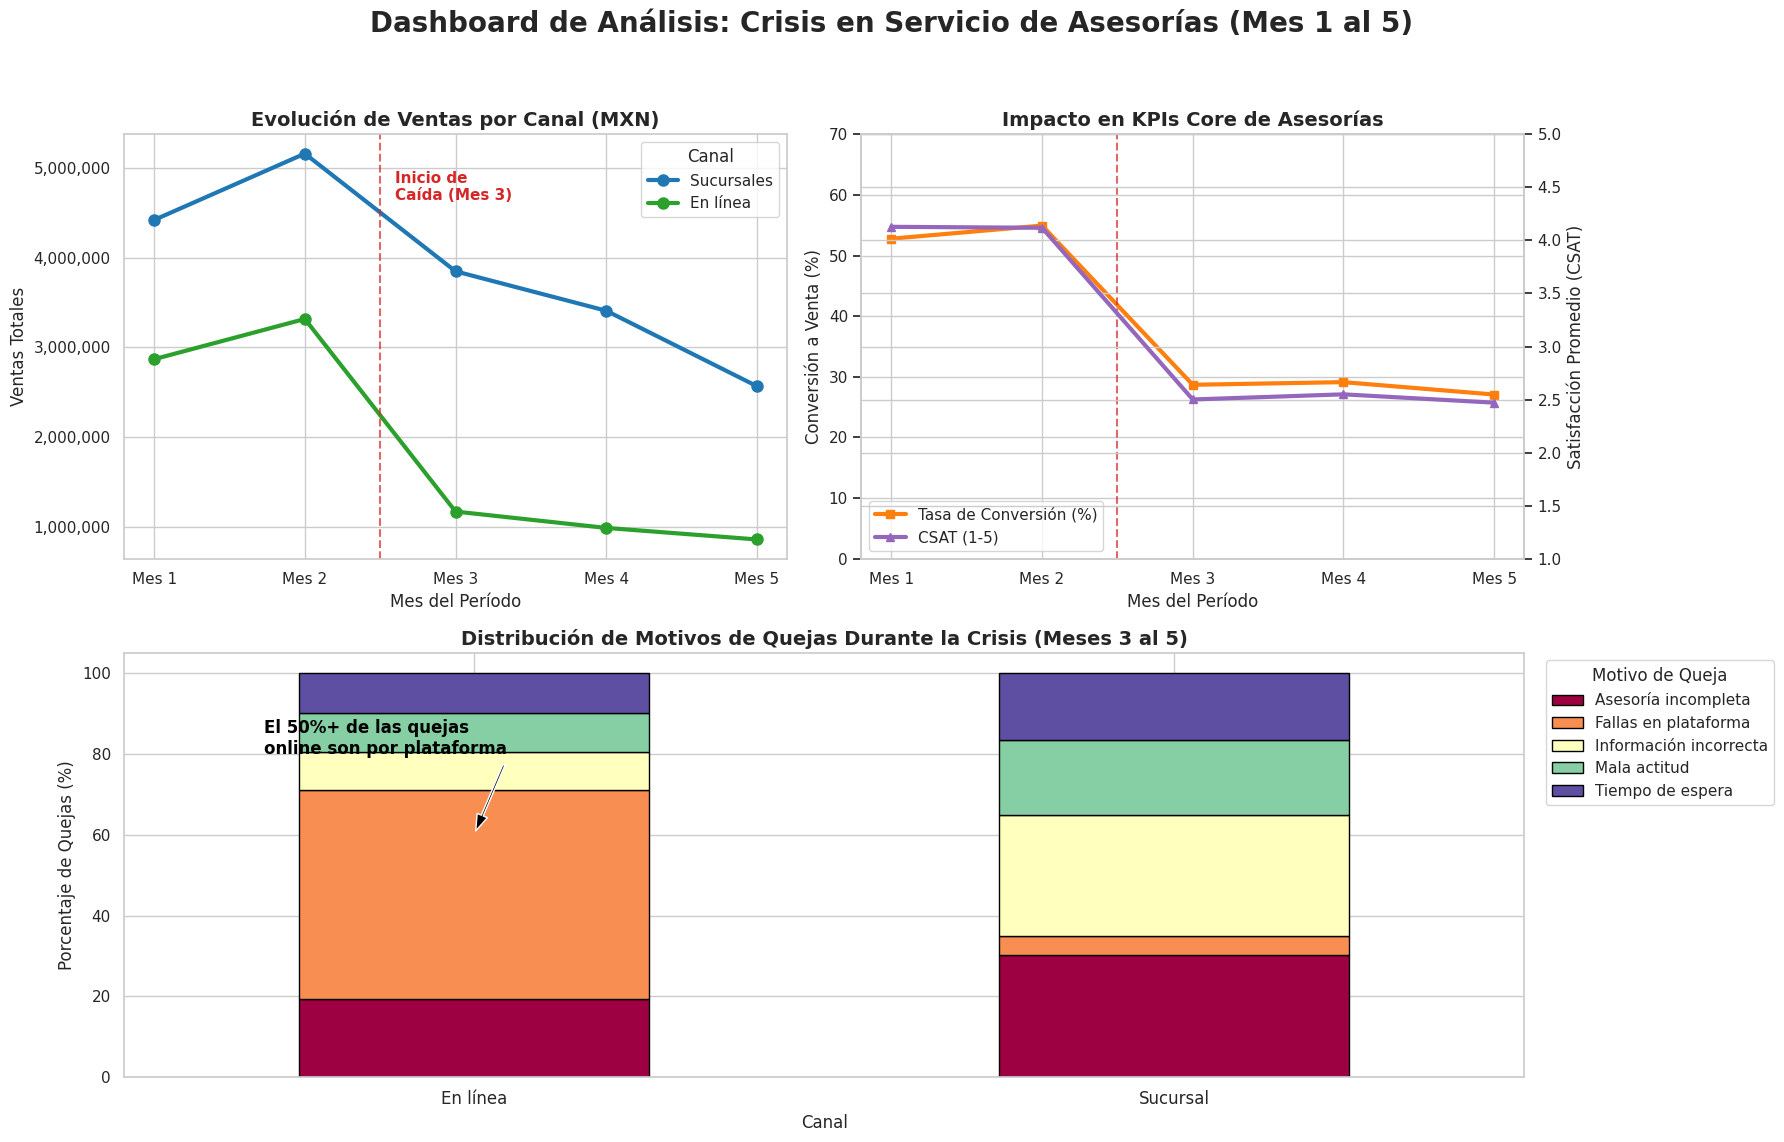

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Configuración de estilo corporativo
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
color_sucursal = '#1f77b4' # Azul
color_linea = '#2ca02c'   # Verde
color_alerta = '#d62728'  # Rojo para métricas negativas

# Crear la figura principal (Dashboard de 3 paneles)
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Dashboard de Análisis: Crisis en Servicio de Asesorías (Mes 1 al 5)', fontsize=20, fontweight='bold', y=0.98)

# ==========================================
# GRÁFICO 1: Caída de Ventas por Canal
# ==========================================
ax1 = plt.subplot(2, 2, 1)
ventas_canal = df_merged[df_merged['Conversion_Venta'] == 1].groupby(['Mes_Num', 'Canal'])['Monto_Venta_MXN'].sum().unstack()

ventas_canal['Sucursal'].plot(kind='line', marker='o', linewidth=3, markersize=8, color=color_sucursal, ax=ax1, label='Sucursales')
ventas_canal['En línea'].plot(kind='line', marker='o', linewidth=3, markersize=8, color=color_linea, ax=ax1, label='En línea')

ax1.set_title('Evolución de Ventas por Canal (MXN)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Mes del Período', fontsize=12)
ax1.set_ylabel('Ventas Totales', fontsize=12)
ax1.set_xticks(range(1, 6))
ax1.set_xticklabels(['Mes 1', 'Mes 2', 'Mes 3', 'Mes 4', 'Mes 5'])
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ',')))
ax1.legend(title='Canal', fontsize=11)
ax1.axvline(x=2.5, color=color_alerta, linestyle='--', alpha=0.7)
ax1.text(2.6, ventas_canal['Sucursal'].max() * 0.9, 'Inicio de\nCaída (Mes 3)', color=color_alerta, fontsize=11, fontweight='bold')

# ==========================================
# GRÁFICO 2: Derrumbe de KPIs (Conversión y CSAT)
# ==========================================
ax2 = plt.subplot(2, 2, 2)
kpis_tendencia = df_merged.groupby('Mes_Num').agg({'Conversion_Venta': 'mean', 'Satisfaccion_Post_Asesoria': 'mean'})

# Eje principal para Conversión
l1 = ax2.plot(kpis_tendencia.index, kpis_tendencia['Conversion_Venta'] * 100, marker='s', color='#ff7f0e', linewidth=3, label='Tasa de Conversión (%)')
ax2.set_ylabel('Conversión a Venta (%)', fontsize=12)
ax2.set_ylim(0, 70)
ax2.set_xlabel('Mes del Período', fontsize=12)
ax2.set_xticks(range(1, 6))
ax2.set_xticklabels(['Mes 1', 'Mes 2', 'Mes 3', 'Mes 4', 'Mes 5'])

# Eje secundario para CSAT
ax2_twin = ax2.twinx()
l2 = ax2_twin.plot(kpis_tendencia.index, kpis_tendencia['Satisfaccion_Post_Asesoria'], marker='^', color='#9467bd', linewidth=3, label='CSAT (1-5)')
ax2_twin.set_ylabel('Satisfacción Promedio (CSAT)', fontsize=12)
ax2_twin.set_ylim(1, 5)

# Unir leyendas
lns = l1 + l2
labs = [l.get_label() for l in lns]
ax2.legend(lns, labs, loc='lower left', fontsize=11)
ax2.set_title('Impacto en KPIs Core de Asesorías', fontsize=14, fontweight='bold')
ax2.axvline(x=2.5, color=color_alerta, linestyle='--', alpha=0.7)

# ==========================================
# GRÁFICO 3: Motivos de Queja Post-Crisis (Mes 3-5)
# ==========================================
ax3 = plt.subplot(2, 1, 2)
# Filtramos solo los meses de crisis
df_crisis = df_quejas[df_quejas['Mes_Num'] >= 3]

# Calculamos porcentajes por canal
quejas_pct = df_crisis.groupby(['Canal', 'Motivo_Queja']).size().unstack(fill_value=0)
quejas_pct = quejas_pct.div(quejas_pct.sum(axis=1), axis=0) * 100

quejas_pct.plot(kind='bar', stacked=True, colormap='Spectral', ax=ax3, edgecolor='black')

ax3.set_title('Distribución de Motivos de Quejas Durante la Crisis (Meses 3 al 5)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Canal', fontsize=12)
ax3.set_ylabel('Porcentaje de Quejas (%)', fontsize=12)
ax3.tick_params(axis='x', rotation=0, labelsize=12)
ax3.legend(title='Motivo de Queja', bbox_to_anchor=(1.01, 1), loc='upper left')

# Añadir anotación fuerte para la plataforma
ax3.annotate('El 50%+ de las quejas\nonline son por plataforma',
             xy=(0, 60), xytext=(-0.3, 80),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
             fontsize=12, fontweight='bold', color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()